# MLSP 2013 Bird Classification Challenge
## Multi-Label Audio Classification

**Opdracht**: Classificeer welke van de 19 vogelsoorten aanwezig zijn in 10-seconden audio-opnames.

**Kernpunten:**
- 19 verschillende vogelsoorten
- Multi-label classificatie (meerdere vogels per opname mogelijk)
- Audio data: 10-sec WAV files, 16kHz, mono
- Output: Probability (0-1) voor elke soort per test opname

---
## Stap 1: Libraries Importeren

In [1]:
# Data verwerking
import numpy as np
import pandas as pd
import os
from pathlib import Path

# Audio verwerking
import librosa
import librosa.display
import soundfile as sf

# Visualisatie
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score
from sklearn.multioutput import MultiOutputClassifier

# Deep Learning (avoor de nn)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Overige utilities
import warnings
warnings.filterwarnings('ignore')

# Plotting stijl
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Alle libraries goed ingeladen!")
print(f"NumPy versie: {np.__version__}")
print(f"Pandas versie: {pd.__version__}")
print(f"Librosa versie: {librosa.__version__}")

Alle libraries goed ingeladen!
NumPy versie: 2.1.3
Pandas versie: 2.3.2
Librosa versie: 0.11.0


## Stap 2: Data Paths en Configuratie

In [2]:
# Data directories
BASE_DIR = Path(r"c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025")
ESSENTIAL_DATA = BASE_DIR / "essential_data"
SUPPLEMENTAL_DATA = BASE_DIR / "supplemental_data"

# Belangrijke files
SPECIES_LIST = ESSENTIAL_DATA / "species_list.txt"
CV_FOLDS = ESSENTIAL_DATA / "CVfolds_2.txt"
REC_ID_TO_FILE = ESSENTIAL_DATA / "rec_id2filename.txt"
LABELS_FILE = ESSENTIAL_DATA / "rec_labels_test_hidden.txt"
SAMPLE_SUBMISSION = ESSENTIAL_DATA / "sample_submission.csv"

# Audio files
SRC_WAVS = ESSENTIAL_DATA / "src_wavs"

# Spectrograms
SPECTROGRAMS = BASE_DIR / "spectrograms"
FILTERED_SPECTROGRAMS = SUPPLEMENTAL_DATA / "filtered_spectrograms"

# Check of alles bestaat
print("Checking data directories...")
for path, name in [
    (ESSENTIAL_DATA, "Essential Data"),
    (SUPPLEMENTAL_DATA, "Supplemental Data"),
    (SRC_WAVS, "WAV Files"),
    (SPECTROGRAMS, "Spectrograms")
]:
    exists = "Bestaat" if path.exists() else "ERROR, Bestaad niet!"
    print(f"{exists} {name}: {path}")

print(f"\n Aantal WAV bestanden: {len(list(SRC_WAVS.glob('*.wav'))) if SRC_WAVS.exists() else 0}")
print(f" Aantal Spectrograms: {len(list(SPECTROGRAMS.glob('*.bmp'))) if SPECTROGRAMS.exists() else 0}")

Checking data directories...
Bestaat Essential Data: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\essential_data
Bestaat Supplemental Data: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\supplemental_data
Bestaat WAV Files: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\essential_data\src_wavs
ERROR, Bestaad niet! Spectrograms: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\spectrograms

 Aantal WAV bestanden: 645
 Aantal Spectrograms: 0


## Stap 3: Data Inladen en Verkennen

In [3]:
# 1. Species lijst inladen
species_df = pd.read_csv(SPECIES_LIST)
print("Vogelsoorten in de dataset:")
print(species_df)
print(f"\nTotaal aantal soorten: {len(species_df)}")

Vogelsoorten in de dataset:
    class_id  code                    species
0          0  BRCR              Brown Creeper
1          1  PAWR               Pacific Wren
2          2  PSFL   Pacific-slope Flycatcher
3          3  RBNU      Red-breasted Nuthatch
4          4  DEJU            Dark-eyed Junco
5          5  OSFL     Olive-sided Flycatcher
6          6  HETH              Hermit Thrush
7          7  CBCH  Chestnut-backed Chickadee
8          8  VATH              Varied Thrush
9          9  HEWA             Hermit Warbler
10        10  SWTH          Swainson's Thrush
11        11  HAFL       Hammond's Flycatcher
12        12  WETA            Western Tanager
13        13  BHGB      Black-headed Grosbeak
14        14  GCKI     Golden Crowned Kinglet
15        15  WAVI             Warbling Vireo
16        16  MGWA     MacGillivray's Warbler
17        17  STJA              Stellar's Jay
18        18  CONI           Common Nighthawk

Totaal aantal soorten: 19


In [4]:
# 2. CV Folds inladen (training/test split)
cv_folds = pd.read_csv(CV_FOLDS)  # Heeft al een header, waarom heeft deze al een header? 
print("Training/Test split:\n")
print(cv_folds['fold'].value_counts().sort_index())
print(f"\n0 = Training set, 1 = Test set")
print(f"Training: {(cv_folds['fold']==0).sum()} opnames")
print(f"Test: {(cv_folds['fold']==1).sum()} opnames")
print(f"\nData types:")
print(cv_folds.dtypes)

Training/Test split:

fold
0    322
1    323
Name: count, dtype: int64

0 = Training set, 1 = Test set
Training: 322 opnames
Test: 323 opnames

Data types:
rec_id    int64
fold      int64
dtype: object


In [5]:
# 3. Labels inladen
# We moeten dit bestand parsen want het formaat is: rec_id,[labels]
labels_data = []
with open(LABELS_FILE, 'r') as f:
    next(f)  # Skip header
    for line in f:
        line = line.strip()
        if ',' in line:
            parts = line.split(',')
            rec_id = int(parts[0])
            # Labels zijn alle getallen na de eerste komma
            labels = [int(x) for x in parts[1:] if x.isdigit()]
            labels_data.append({'rec_id': rec_id, 'labels': labels})
        else:
            # Geen labels (lege regel of alleen rec_id)
            if line.isdigit():
                labels_data.append({'rec_id': int(line), 'labels': []})

labels_df = pd.DataFrame(labels_data)
print("Labels dataset:")
print(labels_df.head(20))
print(f"\nTotaal aantal opnames: {len(labels_df)}")

Labels dataset:
    rec_id    labels
0        0        []
1        1        []
2        2  [11, 12]
3        3        []
4        4        []
5        5      [10]
6        6        []
7        7        []
8        8        []
9        9        []
10      10        []
11      11        []
12      12        []
13      13  [15, 17]
14      14        []
15      15        []
16      16        []
17      17        []
18      18       [1]
19      19       [2]

Totaal aantal opnames: 645


In [6]:
# 4. Alles combineren in één DataFrame
df = labels_df.merge(cv_folds, on='rec_id')

# Identificeer training en test
df['is_train'] = df['fold'] == 0
df['is_test'] = df['fold'] == 1

# Voor training data: bepaal het aantal labels per opname
df['num_labels'] = df['labels'].apply(len)

print("Dataset Overview:")
print(df.head)
print(f"\n{'='*60}")
print("Label statistieken (alleen training data met labels):")
train_with_labels = df[df['is_train'] & (df['num_labels'] > 0)]
print(f"Training opnames met labels: {len(train_with_labels)}")
print(f"Training opnames zonder labels: {(df['is_train'] & (df['num_labels'] == 0)).sum()}")
print(f"Gemiddeld aantal labels per opname: {train_with_labels['num_labels'].mean():.2f}")
print(f"Min labels: {train_with_labels['num_labels'].min()}")
print(f"Max labels: {train_with_labels['num_labels'].max()}")

Dataset Overview:
<bound method NDFrame.head of      rec_id          labels  fold  is_train  is_test  num_labels
0         0              []     1     False     True           0
1         1              []     1     False     True           0
2         2        [11, 12]     0      True    False           2
3         3              []     0      True    False           0
4         4              []     1     False     True           0
..      ...             ...   ...       ...      ...         ...
640     640             [8]     0      True    False           1
641     641  [4, 8, 10, 14]     0      True    False           4
642     642         [4, 15]     0      True    False           2
643     643              []     1     False     True           0
644     644              []     1     False     True           0

[645 rows x 6 columns]>

Label statistieken (alleen training data met labels):
Training opnames met labels: 179
Training opnames zonder labels: 143
Gemiddeld aantal labels

## Stap 4: Data Visualisatie

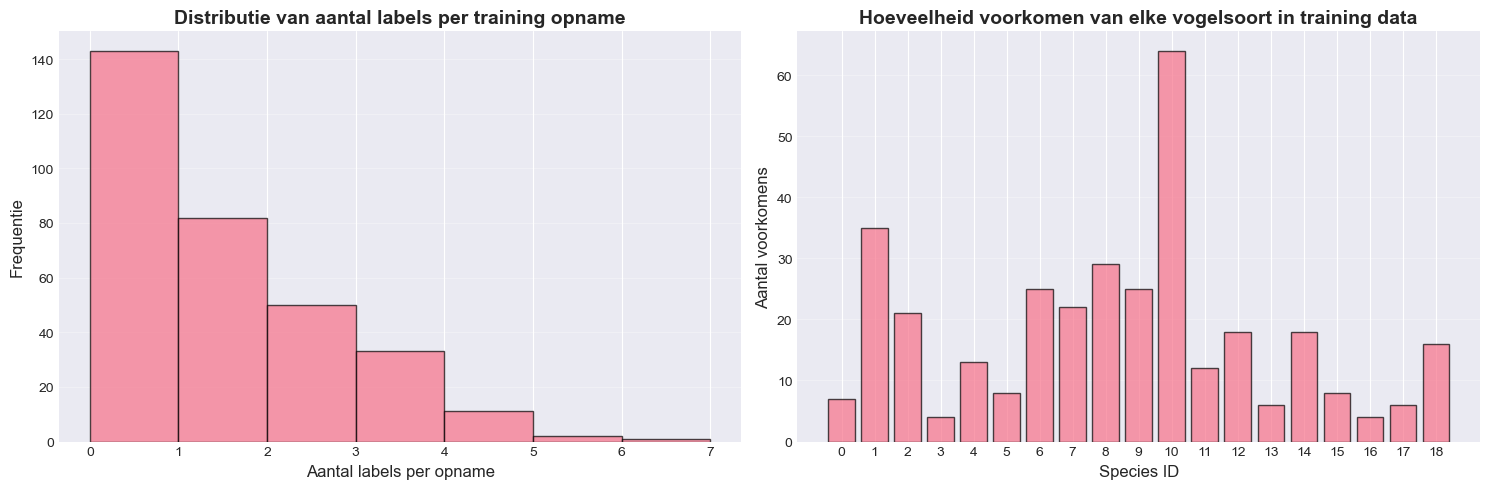


Meest voorkomende soorten:
   0 - Brown Creeper                 :   7 voorkomens
   1 - Pacific Wren                  :  35 voorkomens
   2 - Pacific-slope Flycatcher      :  21 voorkomens
   3 - Red-breasted Nuthatch         :   4 voorkomens
   4 - Dark-eyed Junco               :  13 voorkomens
   5 - Olive-sided Flycatcher        :   8 voorkomens
   6 - Hermit Thrush                 :  25 voorkomens
   7 - Chestnut-backed Chickadee     :  22 voorkomens
   8 - Varied Thrush                 :  29 voorkomens
   9 - Hermit Warbler                :  25 voorkomens


In [7]:
# Visualisatie van label distributie
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Aantal labels per opname (training data)
train_data = df[df['is_train']]
axes[0].hist(train_data['num_labels'], bins=range(8), edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Aantal labels per opname', fontsize=12)
axes[0].set_ylabel('Frequentie', fontsize=12)
axes[0].set_title('Distributie van aantal labels per training opname', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Welke species komen het meest voor?
all_species = []
for labels in train_data['labels']:
    all_species.extend(labels)

species_counts = pd.Series(all_species).value_counts().sort_index()
axes[1].bar(species_counts.index, species_counts.values, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Species ID', fontsize=12)
axes[1].set_ylabel('Aantal voorkomens', fontsize=12)
axes[1].set_title('Hoeveelheid voorkomen van elke vogelsoort in training data', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(19))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMeest voorkomende soorten:")
for species_id, count in species_counts.head(10).items():
    species_name = species_df[species_df['class_id'] == species_id]['species'].values[0]
    print(f"  {species_id:2d} - {species_name:30s}: {count:3d} voorkomens")

## Stap 5: Audio Data Exploratie

Laten we een audio bestand laden en bekijken wat de eigenschappen zijn.

In [8]:
# Haal een training sample met labels
sample_rec = train_data[train_data['num_labels'] > 0].iloc[0]
print(f"Voorbeeld Recording Info:")
print(f"Recording ID: {sample_rec['rec_id']}")
print(f"Labels: {sample_rec['labels']}")
print(f"Species namen:")
for label in sample_rec['labels']:
    species_name = species_df[species_df['class_id'] == label]['species'].values[0]
    print(f"  - {label}: {species_name}")

# Vind het bijbehorende WAV bestand
rec_id_mapping = pd.read_csv(REC_ID_TO_FILE)
wav_filename = rec_id_mapping[rec_id_mapping['rec_id'] == sample_rec['rec_id']]['filename'].values[0]
wav_path = SRC_WAVS / f"{wav_filename}.wav"  # Voeg .wav extensie toe

print(f"\nWAV bestand: {wav_filename}.wav")
print(f"Pad: {wav_path}")
print(f"Bestaat: {wav_path.exists()}")

# Laad het audio bestand
if wav_path.exists():
    audio, sr = librosa.load(wav_path, sr=None)
    duration = len(audio) / sr
    
    print(f"\n🎵 Audio eigenschappen:")
    print(f"Sample rate: {sr} Hz")
    print(f"Duur: {duration:.2f} seconden")
    print(f"Aantal samples: {len(audio)}")
    print(f"Audio shape: {audio.shape}")

Voorbeeld Recording Info:
Recording ID: 2
Labels: [11, 12]
Species namen:
  - 11: Hammond's Flycatcher
  - 12: Western Tanager

WAV bestand: PC1_20090606_050012_0010.wav
Pad: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\essential_data\src_wavs\PC1_20090606_050012_0010.wav
Bestaat: True

🎵 Audio eigenschappen:
Sample rate: 16000 Hz
Duur: 10.00 seconden
Aantal samples: 160000
Audio shape: (160000,)


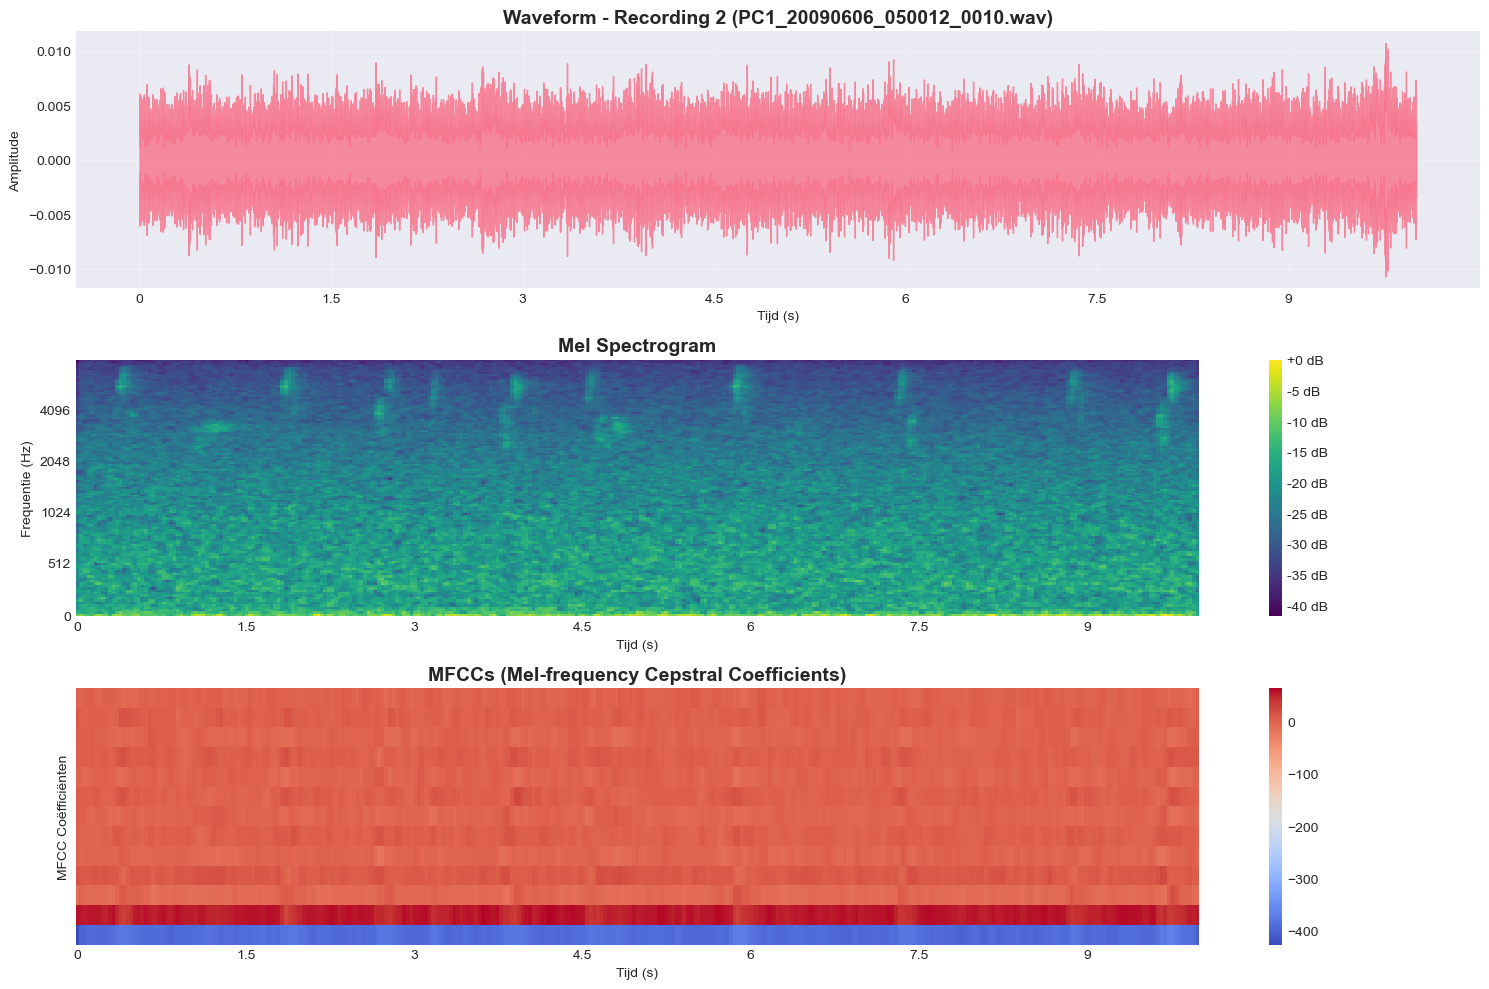


Feature dimensies:
Mel Spectrogram shape: (128, 313)
MFCCs shape: (13, 313)


In [9]:
# Visualisatie van audio sample
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# 1. Waveform
librosa.display.waveshow(audio, sr=sr, ax=axes[0], alpha=0.8)
axes[0].set_title(f'Waveform - Recording {sample_rec["rec_id"]} ({wav_filename}.wav)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tijd (s)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# 2. Spectrogram (Mel)
mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=8000)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                                ax=axes[1], fmax=8000, cmap='viridis')
axes[1].set_title('Mel Spectrogram', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tijd (s)')
axes[1].set_ylabel('Frequentie (Hz)')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

# 3. MFCC (Mel-frequency cepstral coefficients)
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
img2 = librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=axes[2], cmap='coolwarm')
axes[2].set_title('MFCCs (Mel-frequency Cepstral Coefficients)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Tijd (s)')
axes[2].set_ylabel('MFCC Coëfficiënten')
fig.colorbar(img2, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"\nFeature dimensies:")
print(f"Mel Spectrogram shape: {mel_spec.shape}")
print(f"MFCCs shape: {mfccs.shape}")

Nu hebben we inzicht in de data. We gaan nu de data pre processen om het klaar te stomen voor het NN

PRE PROCESSING 1: Windruis verwijderen

De audio bestanden hebben heel veel wind geluid die te horen is. Dit is ruis waar we liever het NN niet op willen trainen. Deze gaan we hieronder verwijderen

In [10]:
# Importeer extra libraries voor noise reduction
from scipy.fft import fft
from scipy import signal

print("Extra libraries voor noise reduction geladen!")

Extra libraries voor noise reduction geladen!


### Stap 1: Functies voor Spectral Analysis

We gaan eerst een functie maken om het spectrogram te berekenen met de gegeven parameters.

In [11]:
Gebruikte_Step = 4
Gebruikte_K = 512
Gebruikte_N = 160000

def create_spectrogram(audio_signal, N=Gebruikte_N, K=Gebruikte_K, Step=Gebruikte_Step):
    
    ##Maakt een spectrogram van een audio signaal met windowing
    
    ##Parameters:
    ##- audio_signal: Het audio signaal (numpy array)
    ##- N: Totaal aantal samples (default: 160000 = 10 sec @ 16kHz)
    ##- K: FFT venster grootte (512 samples)
    ##- Step: Hop size factor (overlapping van vensters)

    #Returns:
    #- Spectrogram als numpy array

    # Hamming window om spectral leakage te verminderen
    window = 0.5 * (1 - np.cos(np.array(range(K)) * 2 * np.pi / (K - 1)))
    
    Spectrogram = []
    
    # Bereken aantal frames
    num_frames = int(Step * len(audio_signal) / K) - Step
    
    for j in range(num_frames):
        # Extract een frame uit het signaal
        start_idx = j * K // Step
        end_idx = (j + Step) * K // Step
        
        if end_idx <= len(audio_signal):
            vec = audio_signal[start_idx:end_idx] * window
            
            # FFT en neem alleen de positieve frequenties
            fft_result = fft(vec, K)[:K // 2]
            Spectrogram.append(np.abs(fft_result))
    
    return np.array(Spectrogram).T  # Transpose voor (freq, time) formaat

print("Spectrogram functie gedefinieerd!")
print("Gebruikte K=", Gebruikte_K)
print("Step=", Gebruikte_Step, ": Overlap factor voor betere tijdsresolutie")
print("Hamming window: Reduceert spectral leakage")

Spectrogram functie gedefinieerd!
Gebruikte K= 512
Step= 4 : Overlap factor voor betere tijdsresolutie
Hamming window: Reduceert spectral leakage


### Stap 2: Noise Reduction met Spectral Subtraction

We gebruiken spectral subtraction: schat het ruis-profiel en trek dit af van het signaal.

In [12]:
# THRESHOLDS - Pas deze aan voor noise reduction
NOISE_FRAMES = 20   # Aantal stilste frames voor ruis schatting
ALPHA = 2.0         # Over-subtraction factor (hoger = meer ruis weg)
BETA = 0.1          # Spectral floor (minimale energie na cleaning)

def reduce_noise_spectral_subtraction(audio_signal, sr=16000):
    """
    Vermindert ruis door spectral subtraction
    """
    # Maak spectrogram
    spec = create_spectrogram(audio_signal)
    
    # Vind de stilste frames (waarschijnlijk alleen ruis)
    frame_energies = np.sum(spec, axis=0)
    noise_frame_indices = np.argsort(frame_energies)[:NOISE_FRAMES]
    
    # Schat het ruis-profiel (gemiddelde van stilste frames)
    noise_profile = np.mean(spec[:, noise_frame_indices], axis=1, keepdims=True)
    
    # Trek ruis af
    cleaned_spec = spec - ALPHA * noise_profile
    
    # Zet negatieve waarden op een minimum niveau (spectral floor)
    cleaned_spec = np.maximum(cleaned_spec, BETA * spec)
    
    return cleaned_spec, noise_profile

print("Noise reduction functie gedefinieerd!")
print(f"   - Noise frames: {NOISE_FRAMES}")
print(f"   - Alpha: {ALPHA} (over-subtraction)")
print(f"   - Beta: {BETA} (spectral floor)")

Noise reduction functie gedefinieerd!
   - Noise frames: 20
   - Alpha: 2.0 (over-subtraction)
   - Beta: 0.1 (spectral floor)


### Stap 3: Test noise reduction op voorbeeld audio

In [13]:
# Test op het eerder geladen audio bestand
print(f"Test noise reduction op Recording {sample_rec['rec_id']}")
print(f"Labels: {sample_rec['labels']}")

# Apply noise reduction
cleaned_spec, noise_profile = reduce_noise_spectral_subtraction(audio, sr)
original_spec = create_spectrogram(audio)

print(f"\nNoise reduction toegepast!")
print(f"Original spectrogram shape: {original_spec.shape}")
print(f"Cleaned spectrogram shape: {cleaned_spec.shape}")

Test noise reduction op Recording 2
Labels: [11, 12]

Noise reduction toegepast!
Original spectrogram shape: (256, 1246)
Cleaned spectrogram shape: (256, 1246)


### Stap 4: Visualisatie Voor vs Na

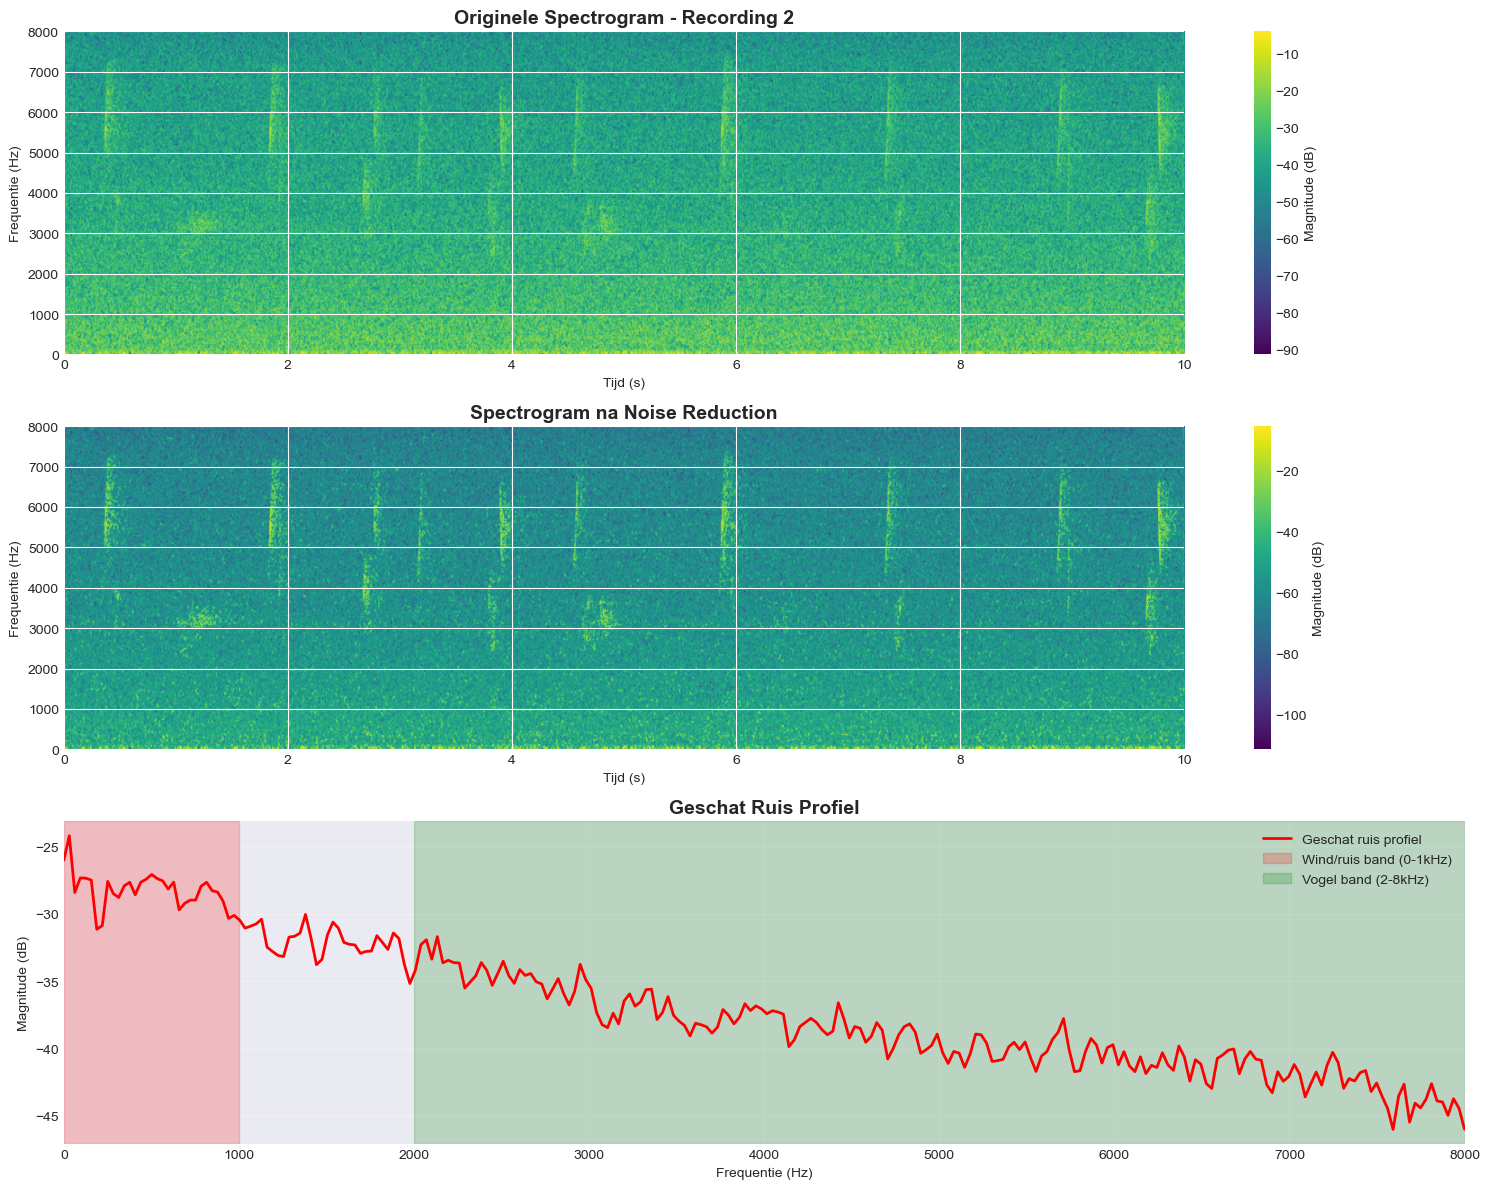


Interpretatie:
- Origineel: Zie veel laag-frequente energie (ruis)
- Na cleaning: Vogel geluiden steken duidelijker uit
- Ruis profiel: Toont welke frequenties als ruis worden beschouwd


In [14]:
# Visualisatie: Origineel vs Cleaned
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Parameters voor visualisatie
K = 512
sr = 16000
freqs = np.linspace(0, sr/2, K//2)
times_spec = np.linspace(0, len(audio)/sr, original_spec.shape[1])

# 1. Originele Spectrogram
im1 = axes[0].imshow(20*np.log10(original_spec + 1e-10), 
                      aspect='auto', origin='lower', cmap='viridis',
                      extent=[0, len(audio)/sr, 0, sr/2])
axes[0].set_title(f'Originele Spectrogram - Recording {sample_rec["rec_id"]}', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tijd (s)')
axes[0].set_ylabel('Frequentie (Hz)')
axes[0].set_ylim([0, 8000])  # Focus op vogel-frequenties
fig.colorbar(im1, ax=axes[0], label='Magnitude (dB)')

# 2. Geschoonde Spectrogram
im2 = axes[1].imshow(20*np.log10(cleaned_spec + 1e-10), 
                      aspect='auto', origin='lower', cmap='viridis',
                      extent=[0, len(audio)/sr, 0, sr/2])
axes[1].set_title('Spectrogram na Noise Reduction', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tijd (s)')
axes[1].set_ylabel('Frequentie (Hz)')
axes[1].set_ylim([0, 8000])
fig.colorbar(im2, ax=axes[1], label='Magnitude (dB)')

# 3. Ruis profiel
axes[2].plot(freqs, 20*np.log10(noise_profile.flatten() + 1e-10), 
             linewidth=2, color='red', label='Geschat ruis profiel')
axes[2].axvspan(0, 1000, alpha=0.2, color='red', label='Wind/ruis band (0-1kHz)')
axes[2].axvspan(2000, 8000, alpha=0.2, color='green', label='Vogel band (2-8kHz)')
axes[2].set_title('Geschat Ruis Profiel', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Frequentie (Hz)')
axes[2].set_ylabel('Magnitude (dB)')
axes[2].set_xlim([0, 8000])
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nInterpretatie:")
print("- Origineel: Zie veel laag-frequente energie (ruis)")
print("- Na cleaning: Vogel geluiden steken duidelijker uit")
print("- Ruis profiel: Toont welke frequenties als ruis worden beschouwd")

In [15]:
# Maak output directory
OUTPUT_DIR = BASE_DIR / "Spectogram_DeNoise"
OUTPUT_DIR.mkdir(exist_ok=True)

def process_and_save_all_spectrograms(df, rec_id_mapping, src_wavs_path, output_path, sr=16000):
    """
    Verwerk alle audio bestanden: pas noise reduction toe en sla spectrograms op als BMP
    """
    print(f"Processing {len(df)} audio files...")
    print(f"Output directory: {output_path}\n")
    
    success_count = 0
    error_count = 0
    
    for idx, row in df.iterrows():
        rec_id = row['rec_id']
        
        # Vind WAV bestand
        wav_filename = rec_id_mapping[rec_id_mapping['rec_id'] == rec_id]['filename'].values[0]
        wav_path = src_wavs_path / f"{wav_filename}.wav"
        
        if not wav_path.exists():
            print(f"WARNING: {wav_path} niet gevonden!")
            error_count += 1
            continue
        
        try:
            # Laad audio
            audio_signal, _ = librosa.load(wav_path, sr=sr)
            
            # Apply noise reduction
            cleaned_spec, noise_prof = reduce_noise_spectral_subtraction(audio_signal, sr)
            
            # Converteer spectrogram naar 8-bit image (0-255)
            # Normaliseer naar dB schaal
            spec_db = 20 * np.log10(cleaned_spec + 1e-10)
            spec_db = spec_db - np.min(spec_db)  # Start bij 0
            spec_db = spec_db / np.max(spec_db) * 255  # Schaal naar 0-255
            spec_img = spec_db.astype(np.uint8)
            
            # Sla op als BMP
            output_file = output_path / f"{wav_filename}_cleaned.bmp"
            plt.imsave(output_file, spec_img, cmap='gray', format='bmp')
            
            success_count += 1
            
            # Progress indicator
            if (idx + 1) % 50 == 0:
                print(f"  Processed {idx + 1}/{len(df)} files... ({success_count} success, {error_count} errors)")
                
        except Exception as e:
            print(f"ERROR processing {wav_filename}: {e}")
            error_count += 1
    
    print(f"\n{'='*60}")
    print(f"Processing complete!")
    print(f"  Success: {success_count}/{len(df)}")
    print(f"  Errors: {error_count}/{len(df)}")
    print(f"  Saved to: {output_path}")
    
    return success_count, error_count

# Run processing
print("Starting batch processing met noise reduction...")
print("Dit kan een paar minuten duren...\n")

success, errors = process_and_save_all_spectrograms(df, rec_id_mapping, SRC_WAVS, OUTPUT_DIR)

print(f"\nKlaar! Je kunt de schone spectrograms vinden in: {OUTPUT_DIR}")

Starting batch processing met noise reduction...
Dit kan een paar minuten duren...

Processing 645 audio files...
Output directory: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\Spectogram_DeNoise

  Processed 50/645 files... (50 success, 0 errors)
  Processed 100/645 files... (100 success, 0 errors)
  Processed 150/645 files... (150 success, 0 errors)
  Processed 200/645 files... (200 success, 0 errors)
  Processed 250/645 files... (250 success, 0 errors)
  Processed 300/645 files... (300 success, 0 errors)
  Processed 350/645 files... (350 success, 0 errors)
  Processed 400/645 files... (400 success, 0 errors)
  Processed 450/645 files... (450 success, 0 errors)
  Processed 500/645 files... (500 success, 0 errors)
  Processed 550/645 files... (550 success, 0 errors)
  Processed 600/645 files... (600 success, 0 errors)

Processing complete!
  Success: 645/645
  Errors: 0/645
  Saved to: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\Spectogram_DeNoise

Klaar! Je

In [16]:
# THRESHOLDS - Pas deze aan voor vogel segmentatie
INTENSITY_THRESHOLD_PERCENTILE = 90  # Percentile voor intensity threshold (hoger = alleen sterkste signalen)
MIN_DURATION_FRAMES = 1             # Minimale duur van een vogel signaal in frames
MEDIAN_FILTER_SIZE = 3               # Grootte van median filter voor ruis verwijdering

# Maak output directory
OUTPUT_BIRD_ONLY = BASE_DIR / "Spectogram_Only_Bird_Noises"
OUTPUT_BIRD_ONLY.mkdir(exist_ok=True)

def isolate_bird_sounds(cleaned_spec):
    """
    Isoleer alleen de vogel geluiden uit een spectrogram door adaptive thresholding
    """
    # Converteer naar dB
    spec_db = 20 * np.log10(cleaned_spec + 1e-10)
    
    # Bereken adaptive threshold per frequentie bin
    threshold = np.percentile(spec_db, INTENSITY_THRESHOLD_PERCENTILE, axis=1, keepdims=True)
    
    # Maak binaire mask: alleen waarden boven threshold
    bird_mask = spec_db > threshold
    
    # Apply median filter om kleine ruis punten te verwijderen
    from scipy.ndimage import median_filter
    bird_mask = median_filter(bird_mask.astype(float), size=(MEDIAN_FILTER_SIZE, MEDIAN_FILTER_SIZE))
    bird_mask = bird_mask > 0.5
    
    # Verwijder korte events (temporal filtering)
    for freq_idx in range(bird_mask.shape[0]):
        # Tel opeenvolgende True waarden
        counts = []
        count = 0
        for time_idx in range(bird_mask.shape[1]):
            if bird_mask[freq_idx, time_idx]:
                count += 1
            else:
                if count > 0:
                    counts.append((time_idx - count, count))
                count = 0
        if count > 0:
            counts.append((bird_mask.shape[1] - count, count))
        
        # Verwijder korte segmenten
        for start, duration in counts:
            if duration < MIN_DURATION_FRAMES:
                bird_mask[freq_idx, start:start+duration] = False
    
    # Apply mask: alleen vogel geluiden behouden, rest = 0
    bird_only_spec = np.where(bird_mask, cleaned_spec, 0)
    
    return bird_only_spec, bird_mask

def process_and_save_bird_only_spectrograms(df, rec_id_mapping, src_wavs_path, output_path, sr=16000):
    """
    Verwerk alle audio: noise reduction + vogel isolatie, sla op als BMP
    """
    print(f"Processing {len(df)} audio files voor bird-only segmentatie...")
    print(f"Output directory: {output_path}\n")
    print(f"Thresholds:")
    print(f"  - Intensity percentile: {INTENSITY_THRESHOLD_PERCENTILE}")
    print(f"  - Min duration: {MIN_DURATION_FRAMES} frames")
    print(f"  - Median filter: {MEDIAN_FILTER_SIZE}x{MEDIAN_FILTER_SIZE}\n")
    
    success_count = 0
    error_count = 0
    
    for idx, row in df.iterrows():
        rec_id = row['rec_id']
        
        # Vind WAV bestand
        wav_filename = rec_id_mapping[rec_id_mapping['rec_id'] == rec_id]['filename'].values[0]
        wav_path = src_wavs_path / f"{wav_filename}.wav"
        
        if not wav_path.exists():
            print(f"WARNING: {wav_path} niet gevonden!")
            error_count += 1
            continue
        
        try:
            # Laad audio
            audio_signal, _ = librosa.load(wav_path, sr=sr)
            
            # Apply noise reduction
            cleaned_spec, _ = reduce_noise_spectral_subtraction(audio_signal, sr)
            
            # Isoleer vogel geluiden
            bird_only_spec, bird_mask = isolate_bird_sounds(cleaned_spec)
            
            # Converteer naar 8-bit image (0-255)
            spec_db = 20 * np.log10(bird_only_spec + 1e-10)
            
            # Alleen normaliseren waar er bird signals zijn
            if np.any(bird_mask):
                bird_values = spec_db[bird_mask]
                min_val = np.min(bird_values)
                max_val = np.max(bird_values)
                
                # Normaliseer alleen de vogel geluiden
                spec_normalized = np.zeros_like(spec_db)
                spec_normalized[bird_mask] = (bird_values - min_val) / (max_val - min_val + 1e-10) * 255
            else:
                spec_normalized = np.zeros_like(spec_db)
            
            spec_img = spec_normalized.astype(np.uint8)
            
            # Sla op als BMP
            output_file = output_path / f"{wav_filename}_bird_only.bmp"
            plt.imsave(output_file, spec_img, cmap='gray', format='bmp')
            
            success_count += 1
            
            # Progress indicator
            if (idx + 1) % 50 == 0:
                print(f"  Processed {idx + 1}/{len(df)} files... ({success_count} success, {error_count} errors)")
                
        except Exception as e:
            print(f"ERROR processing {wav_filename}: {e}")
            error_count += 1
    
    print(f"\n{'='*60}")
    print(f"Processing complete!")
    print(f"  Success: {success_count}/{len(df)}")
    print(f"  Errors: {error_count}/{len(df)}")
    print(f"  Saved to: {output_path}")
    
    return success_count, error_count

# Run processing
print("Starting bird-only segmentatie...")
print("Dit kan een paar minuten duren...\n")

success_bird, errors_bird = process_and_save_bird_only_spectrograms(df, rec_id_mapping, SRC_WAVS, OUTPUT_BIRD_ONLY)

print(f"\nKlaar! Bird-only spectrograms in: {OUTPUT_BIRD_ONLY}")

Starting bird-only segmentatie...
Dit kan een paar minuten duren...

Processing 645 audio files voor bird-only segmentatie...
Output directory: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\Spectogram_Only_Bird_Noises

Thresholds:
  - Intensity percentile: 90
  - Min duration: 1 frames
  - Median filter: 3x3

  Processed 50/645 files... (50 success, 0 errors)
  Processed 100/645 files... (100 success, 0 errors)
  Processed 150/645 files... (150 success, 0 errors)
  Processed 200/645 files... (200 success, 0 errors)
  Processed 250/645 files... (250 success, 0 errors)
  Processed 300/645 files... (300 success, 0 errors)
  Processed 350/645 files... (350 success, 0 errors)
  Processed 400/645 files... (400 success, 0 errors)
  Processed 450/645 files... (450 success, 0 errors)
  Processed 500/645 files... (500 success, 0 errors)
  Processed 550/645 files... (550 success, 0 errors)
  Processed 600/645 files... (600 success, 0 errors)

Processing complete!
  Success: 645/645
  

### Stap 7: Segment Detectie en Visualisatie

Nu gaan we vogel segmenten detecteren en deze markeren met rechthoeken op de spectrograms.

In [17]:
# Extra imports voor segment detectie
from skimage.morphology import disk, remove_small_objects
from skimage.filters.rank import gradient
from skimage.util import img_as_ubyte
import matplotlib.patches as patches
import scipy as sp

print("Extra libraries voor segment detectie geladen!")

Extra libraries voor segment detectie geladen!


In [18]:
# THRESHOLDS - Pas deze aan voor segment detectie
SEGMENT_PERCENTILE = 90      # Percentile voor binary threshold (hoger = minder segmenten)
MIN_SEGMENT_SIZE = 99        # Minimale grootte van segment in pixels
GRADIENT_DISK_SIZE = 3       # Grootte van disk voor gradient berekening

def pic_to_ubyte(pic):
    """Converteer array naar 8-bit unsigned integer"""
    a = (pic - np.min(pic)) / (np.max(pic) - np.min(pic) + 1e-10)
    a = img_as_ubyte(a)
    return a

def detect_bird_segments(cleaned_spec, use_log=True):
    """
    Detecteer vogel segmenten in een spectrogram met morphological operations
    
    Gebaseerd op test.ipynb methode maar gebruikt jouw cleaned spectrogram
    
    Returns:
    - segment_bounds: List van [y_min, y_max, x_min, x_max] voor elk segment
    - labeled_segments: 2D array met gelabelde segmenten
    - processed_spec: Spectrogram gebruikt voor visualisatie
    """
    # Transpose en flip (zoals in test.ipynb)
    mypic = np.transpose(cleaned_spec)
    mypic_rev = np.flipud(mypic)
    
    # Focus op relevante frequentie range (eerste 200 bins)
    mypic_rev_small = mypic_rev[:200, :]
    
    # Log transform (optioneel)
    if use_log:
        mypic_processed = np.log10(mypic_rev_small + 0.001)
    else:
        mypic_processed = mypic_rev_small
    
    # STAP 1: Gaussian filtering
    mypic_gauss = sp.ndimage.gaussian_filter(mypic_processed, sigma=3)
    
    # STAP 2: Gradient detection
    mypic_gauss_ubyte = pic_to_ubyte(mypic_gauss)
    mypic_grad = gradient(mypic_gauss_ubyte, disk(GRADIENT_DISK_SIZE))
    
    # STAP 3: Binary thresholding
    mypic_grad_bin = mypic_grad > np.percentile(mypic_grad, SEGMENT_PERCENTILE)
    
    # STAP 4: Morphological operations (opening -> closing)
    mypic_grad_bin_close = sp.ndimage.binary_closing(
        sp.ndimage.binary_opening(mypic_grad_bin)
    )
    
    # STAP 5: Fill holes
    bfh = sp.ndimage.binary_fill_holes(mypic_grad_bin_close)
    
    # STAP 6: Remove small objects
    bfh_rm = remove_small_objects(bfh, MIN_SEGMENT_SIZE)
    
    # STAP 7: Label segmenten
    labeled_segments, num_segments = sp.ndimage.label(bfh_rm)
    
    # STAP 8: Extract segment bounds
    segment_bounds = []
    for seg_id in range(1, num_segments + 1):
        current_segment = (labeled_segments == seg_id) * 1
        
        # X bounds (time)
        xr = current_segment.max(axis=0)
        xr_max = np.max(xr * np.arange(len(xr)))
        xr[xr == 0] = xr.shape[0]
        xr_min = np.argmin(xr)
        
        # Y bounds (frequency)
        yr = current_segment.max(axis=1)
        yr_max = np.max(yr * np.arange(len(yr)))
        yr[yr == 0] = yr.shape[0]
        yr_min = np.argmin(yr)
        
        segment_bounds.append([yr_min, yr_max, xr_min, xr_max])
    
    return segment_bounds, labeled_segments, mypic_gauss

print("Segment detectie functie gedefinieerd!")
print(f"   - Percentile threshold: {SEGMENT_PERCENTILE}")
print(f"   - Min segment size: {MIN_SEGMENT_SIZE} pixels")
print(f"   - Gradient disk size: {GRADIENT_DISK_SIZE}")

Segment detectie functie gedefinieerd!
   - Percentile threshold: 90
   - Min segment size: 99 pixels
   - Gradient disk size: 3


In [19]:
# Test segment detectie op ons voorbeeld bestand
print(f"Test segment detectie op Recording {sample_rec['rec_id']}")

# Gebruik de cleaned spectrogram
segment_bounds, labeled_segments, processed_spec = detect_bird_segments(cleaned_spec, use_log=True)

print(f"\nAantal gedetecteerde segmenten: {len(segment_bounds)}")
print(f"\nSegment details:")
for idx, (y_min, y_max, x_min, x_max) in enumerate(segment_bounds):
    width = x_max - x_min
    height = y_max - y_min
    area = width * height
    print(f"  Segment {idx+1}: Positie=({x_min}-{x_max}, {y_min}-{y_max}), "
          f"Grootte=({width}x{height}), Area={area} pixels")

Test segment detectie op Recording 2

Aantal gedetecteerde segmenten: 4

Segment details:
  Segment 1: Positie=(1-8, 1-194), Grootte=(7x193), Area=1351 pixels
  Segment 2: Positie=(140-215, 5-36), Grootte=(75x31), Area=2325 pixels
  Segment 3: Positie=(77-141, 27-49), Grootte=(64x22), Area=1408 pixels
  Segment 4: Positie=(142-220, 125-146), Grootte=(78x21), Area=1638 pixels


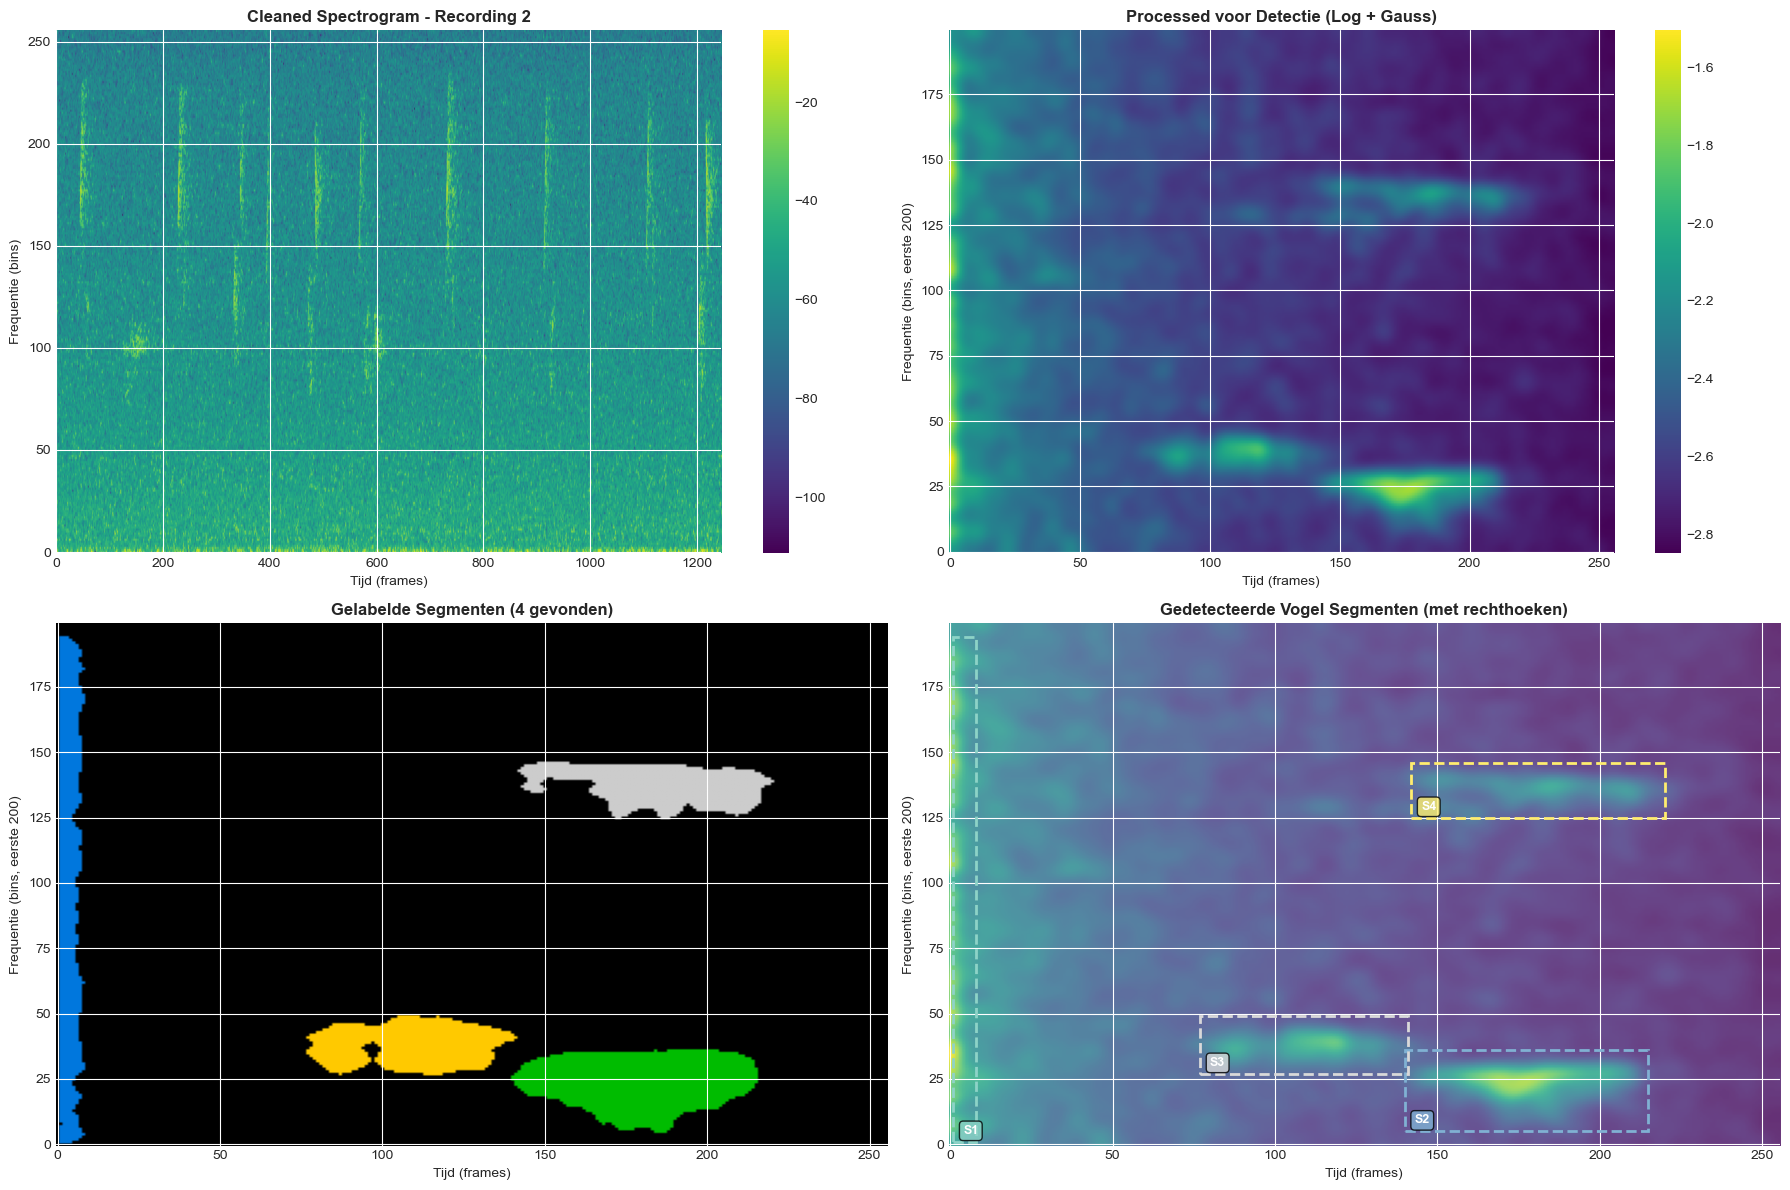


Interpretatie:
- Rechthoeken markeren gedetecteerde vogel geluiden
- Elk segment krijgt een unieke kleur en nummer
- Grotere segmenten zijn waarschijnlijk duidelijkere vogel geluiden


In [20]:
# Visualisatie: Spectrogram met segment rechthoeken
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Cleaned spectrogram (origineel)
im1 = axes[0, 0].imshow(20*np.log10(cleaned_spec + 1e-10), 
                         aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title(f'Cleaned Spectrogram - Recording {sample_rec["rec_id"]}', 
                      fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tijd (frames)')
axes[0, 0].set_ylabel('Frequentie (bins)')
fig.colorbar(im1, ax=axes[0, 0])

# 2. Processed spectrogram voor detectie
im2 = axes[0, 1].imshow(processed_spec, aspect='auto', origin='lower', cmap='viridis')
axes[0, 1].set_title('Processed voor Detectie (Log + Gauss)', 
                      fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tijd (frames)')
axes[0, 1].set_ylabel('Frequentie (bins, eerste 200)')
fig.colorbar(im2, ax=axes[0, 1])

# 3. Labeled segments (gekleurde segmenten)
im3 = axes[1, 0].imshow(labeled_segments, aspect='auto', origin='lower', 
                         cmap='nipy_spectral')
axes[1, 0].set_title(f'Gelabelde Segmenten ({len(segment_bounds)} gevonden)', 
                      fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tijd (frames)')
axes[1, 0].set_ylabel('Frequentie (bins, eerste 200)')

# 4. Spectrogram met rechthoeken rond segmenten
im4 = axes[1, 1].imshow(processed_spec, aspect='auto', origin='lower', 
                         cmap='viridis', alpha=0.8)
axes[1, 1].set_title('Gedetecteerde Vogel Segmenten (met rechthoeken)', 
                      fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tijd (frames)')
axes[1, 1].set_ylabel('Frequentie (bins, eerste 200)')

# Teken rechthoeken rond elk segment
colors = plt.cm.Set3(np.linspace(0, 1, max(len(segment_bounds), 1)))
for idx, (y_min, y_max, x_min, x_max) in enumerate(segment_bounds):
    rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                             linewidth=2, edgecolor=colors[idx],
                             facecolor='none', linestyle='--')
    axes[1, 1].add_patch(rect)
    
    # Voeg segment nummer toe
    axes[1, 1].text(x_min + 3, y_min + 3, f'S{idx+1}',
                    color='white', fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', 
                             facecolor=colors[idx], alpha=0.8))

plt.tight_layout()
plt.show()

print("\nInterpretatie:")
print("- Rechthoeken markeren gedetecteerde vogel geluiden")
print("- Elk segment krijgt een unieke kleur en nummer")
print("- Grotere segmenten zijn waarschijnlijk duidelijkere vogel geluiden")

### Stap 8: Batch Processing - Spectrograms met Segment Markers

Nu gaan we alle bestanden verwerken en spectrograms opslaan met rechthoeken rond gedetecteerde vogel segmenten.

In [21]:
# Maak output directory voor segmented spectrograms
OUTPUT_SEGMENTS = BASE_DIR / "Spectogram_With_Segments"
OUTPUT_SEGMENTS.mkdir(exist_ok=True)

def process_and_save_with_segments(df, rec_id_mapping, src_wavs_path, output_path, sr=16000):
    """
    Verwerk alle audio: noise reduction + segment detectie, sla op als BMP met rechthoeken
    """
    print(f"Processing {len(df)} audio files met segment detectie...")
    print(f"Output directory: {output_path}\n")
    
    success_count = 0
    error_count = 0
    total_segments = 0
    
    for idx, row in df.iterrows():
        rec_id = row['rec_id']
        
        # Vind WAV bestand
        wav_filename = rec_id_mapping[rec_id_mapping['rec_id'] == rec_id]['filename'].values[0]
        wav_path = src_wavs_path / f"{wav_filename}.wav"
        
        if not wav_path.exists():
            print(f"WARNING: {wav_path} niet gevonden!")
            error_count += 1
            continue
        
        try:
            # Laad audio
            audio_signal, _ = librosa.load(wav_path, sr=sr)
            
            # Apply noise reduction
            cleaned_spec, _ = reduce_noise_spectral_subtraction(audio_signal, sr)
            
            # Detecteer segmenten
            segment_bounds, labeled_segments, processed_spec = detect_bird_segments(cleaned_spec, use_log=True)
            total_segments += len(segment_bounds)
            
            # Maak visualisatie met matplotlib
            fig, ax = plt.subplots(figsize=(12, 6))
            
            # Plot spectrogram
            im = ax.imshow(processed_spec, aspect='auto', origin='lower', 
                          cmap='viridis', interpolation='nearest')
            
            # Teken rechthoeken rond segmenten
            colors = plt.cm.Set3(np.linspace(0, 1, max(len(segment_bounds), 1)))
            for seg_idx, (y_min, y_max, x_min, x_max) in enumerate(segment_bounds):
                rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                         linewidth=2, edgecolor=colors[seg_idx],
                                         facecolor='none', linestyle='-', alpha=0.9)
                ax.add_patch(rect)
                
                # Voeg segment nummer toe
                ax.text(x_min + 2, y_min + 2, f'{seg_idx+1}',
                       color='white', fontsize=8, fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.2', 
                                facecolor=colors[seg_idx], alpha=0.9))
            
            ax.set_title(f'{wav_filename} - {len(segment_bounds)} segmenten', 
                        fontsize=10, fontweight='bold')
            ax.set_xlabel('Tijd (frames)')
            ax.set_ylabel('Frequentie (bins)')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            
            # Sla op als BMP
            output_file = output_path / f"{wav_filename}_segments.png"
            plt.savefig(output_file, dpi=150, bbox_inches='tight')
            plt.close(fig)
            
            success_count += 1
            
            # Progress indicator
            if (idx + 1) % 50 == 0:
                avg_segments = total_segments / success_count if success_count > 0 else 0
                print(f"  Processed {idx + 1}/{len(df)} files... "
                      f"({success_count} success, {error_count} errors, "
                      f"avg {avg_segments:.1f} segments/file)")
                
        except Exception as e:
            print(f"ERROR processing {wav_filename}: {e}")
            error_count += 1
    
    avg_segments = total_segments / success_count if success_count > 0 else 0
    
    print(f"\n{'='*60}")
    print(f"Processing complete!")
    print(f"  Success: {success_count}/{len(df)}")
    print(f"  Errors: {error_count}/{len(df)}")
    print(f"  Total segments detected: {total_segments}")
    print(f"  Average segments per file: {avg_segments:.2f}")
    print(f"  Saved to: {output_path}")
    
    return success_count, error_count, total_segments

# Run processing
print("Starting batch processing met segment detectie...")
print("Dit kan een paar minuten duren...\n")

success_seg, errors_seg, total_segs = process_and_save_with_segments(
    df, rec_id_mapping, SRC_WAVS, OUTPUT_SEGMENTS
)

print(f"\nKlaar! Spectrograms met segmenten in: {OUTPUT_SEGMENTS}")

Starting batch processing met segment detectie...
Dit kan een paar minuten duren...

Processing 645 audio files met segment detectie...
Output directory: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\Spectogram_With_Segments

  Processed 50/645 files... (50 success, 0 errors, avg 7.1 segments/file)
  Processed 100/645 files... (100 success, 0 errors, avg 6.4 segments/file)
  Processed 150/645 files... (150 success, 0 errors, avg 5.9 segments/file)
  Processed 200/645 files... (200 success, 0 errors, avg 6.1 segments/file)
  Processed 250/645 files... (250 success, 0 errors, avg 6.1 segments/file)
  Processed 300/645 files... (300 success, 0 errors, avg 5.9 segments/file)
  Processed 350/645 files... (350 success, 0 errors, avg 5.9 segments/file)
  Processed 400/645 files... (400 success, 0 errors, avg 6.0 segments/file)
  Processed 450/645 files... (450 success, 0 errors, avg 5.9 segments/file)
  Processed 500/645 files... (500 success, 0 errors, avg 5.8 segments/file)
  Pr

## Stap 9: Neural Network - Feature Extraction

Nu gaan we de voorverwerkte spectrograms gebruiken om een neural network te trainen.

In [22]:
# Functie om spectrograms te laden als features
def load_spectrogram_features(wav_filename, spectrogram_dir, target_shape=(256, 256)):
    """
    Laad een spectrogram BMP file en resize naar target shape
    """
    spec_file = spectrogram_dir / f"{wav_filename}_cleaned.bmp"
    
    if not spec_file.exists():
        return None
    
    # Laad BMP als grayscale image
    img = plt.imread(spec_file)
    
    # Als image RGB is, converteer naar grayscale
    if len(img.shape) == 3:
        img = img[:, :, 0]
    
    # Resize naar target shape
    from skimage.transform import resize
    img_resized = resize(img, target_shape, anti_aliasing=True, mode='reflect')
    
    # Normaliseer naar 0-1
    img_normalized = (img_resized - img_resized.min()) / (img_resized.max() - img_resized.min() + 1e-10)
    
    return img_normalized

print("Spectrogram loader functie gedefinieerd!")
print(f"Target shape: 256x256 pixels")
print("Output: Genormaliseerde grayscale images (0-1)")

Spectrogram loader functie gedefinieerd!
Target shape: 256x256 pixels
Output: Genormaliseerde grayscale images (0-1)


In [23]:
# Laad alle spectrograms voor training en test
print("Laden van spectrograms...")
print("Dit kan een paar minuten duren...\n")

X_data = []  # Features (spectrograms)
y_data = []  # Labels (multi-label binary)
rec_ids = []  # Recording IDs
is_train_flags = []  # Train/test indicator

failed_count = 0

for idx, row in df.iterrows():
    rec_id = row['rec_id']
    wav_filename = rec_id_mapping[rec_id_mapping['rec_id'] == rec_id]['filename'].values[0]
    
    # Laad spectrogram
    spec_features = load_spectrogram_features(wav_filename, OUTPUT_DIR)
    
    if spec_features is None:
        failed_count += 1
        continue
    
    # Maak multi-label binary vector (19 soorten)
    label_vector = np.zeros(19, dtype=np.float32)
    for label in row['labels']:
        label_vector[label] = 1.0
    
    X_data.append(spec_features)
    y_data.append(label_vector)
    rec_ids.append(rec_id)
    is_train_flags.append(row['is_train'])
    
    if (idx + 1) % 100 == 0:
        print(f"  Geladen: {idx + 1}/{len(df)} ({failed_count} failed)")

# Converteer naar numpy arrays
X_data = np.array(X_data)
y_data = np.array(y_data)
rec_ids = np.array(rec_ids)
is_train_flags = np.array(is_train_flags)

print(f"\n{'='*60}")
print(f"Data geladen!")
print(f"  Totaal samples: {len(X_data)}")
print(f"  Failed: {failed_count}")
print(f"  Features shape: {X_data.shape}")
print(f"  Labels shape: {y_data.shape}")

# Split in train en test
X_train = X_data[is_train_flags]
y_train = y_data[is_train_flags]
X_test = X_data[~is_train_flags]
y_test = y_data[~is_train_flags]
test_rec_ids = rec_ids[~is_train_flags]

print(f"\nTrain/Test Split:")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")
print(f"  Training labels met vogels: {(y_train.sum(axis=1) > 0).sum()}")
print(f"  Training labels zonder vogels: {(y_train.sum(axis=1) == 0).sum()}")

Laden van spectrograms...
Dit kan een paar minuten duren...

  Geladen: 100/645 (0 failed)
  Geladen: 200/645 (0 failed)
  Geladen: 300/645 (0 failed)
  Geladen: 400/645 (0 failed)
  Geladen: 500/645 (0 failed)
  Geladen: 600/645 (0 failed)

Data geladen!
  Totaal samples: 645
  Failed: 0
  Features shape: (645, 256, 256)
  Labels shape: (645, 19)

Train/Test Split:
  Training samples: 322
  Test samples: 323
  Training labels met vogels: 179
  Training labels zonder vogels: 143


## Stap 10: CNN Model Architectuur

We bouwen een Convolutional Neural Network (CNN) voor multi-label classificatie.

In [42]:
# Reshape data voor CNN (voeg channel dimensie toe)
X_train_cnn = X_train[..., np.newaxis]  # Shape: (samples, 256, 256, 1)
X_test_cnn = X_test[..., np.newaxis]

print(f"Input shape voor CNN: {X_train_cnn.shape}")
print(f"Output shape (labels): {y_train.shape}")
print(f"\nMulti-label classificatie: elke sample kan meerdere labels hebben")
print(f"19 outputs met sigmoid activatie (0-1 probability per soort)")

Input shape voor CNN: (322, 256, 256, 1)
Output shape (labels): (322, 19)

Multi-label classificatie: elke sample kan meerdere labels hebben
19 outputs met sigmoid activatie (0-1 probability per soort)


In [43]:
# Bouw CNN Model
def build_bird_classifier():
    """
    Verbeterd CNN model voor vogel classificatie
    
    Architectuur:
    - 4 Conv2D lagen met meer filters en dubbele convoluties
    - Minder dropout voor betere feature learning
    - Grotere Dense layers voor complexe patronen
    - Sigmoid output voor multi-label (19 soorten)
    """
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=(256, 256, 1)),

        # Conv Block 1: Basic features (64 filters)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.15),
        
        # Conv Block 2: Mid-level features (128 filters)
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.15),
        
        # Conv Block 3: High-level features (256 filters)
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        # Conv Block 4: Complex patterns (512 filters)
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        # Flatten en Dense layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        
        # Output layer: 19 soorten, SIGMOID voor multi-label (meerdere vogels tegelijk)
        layers.Dense(19, activation='sigmoid')
    ])
    
    return model

# Maak model
model = build_bird_classifier()

# Build model expliciet (voor count_params())
model.build(input_shape=(None, 256, 256, 1))

# Compileer model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # Voor multi-label classificatie
    metrics=[
        'binary_accuracy', 
        keras.metrics.AUC(name='auc', multi_label=True),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# Toon model architectuur
print("CNN Model Architectuur:\n")
model.summary()

print(f"\n{'='*60}")
print("Model configuratie:")
print("  Optimizer: Adam (lr=0.001)")
print("  Loss: Binary Crossentropy (multi-label)")
print("  Metrics: Binary Accuracy, AUC, Precision, Recall")
print("  Total parameters: {:,}".format(model.count_params()))

CNN Model Architectuur:



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    67,109,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 512)            │         2,04

 Total params: 71,936,723 (274.42 MB)

 Trainable params: 71,933,267 (274.40 MB)

 Non-trainable params: 3,456 (13.50 KB)


Model configuratie:
  Optimizer: Adam (lr=0.001)
  Loss: Binary Crossentropy (multi-label)
  Metrics: Binary Accuracy, AUC, Precision, Recall
  Total parameters: 71,936,723


## Stap 11: Model Training

Nu gaan we het model trainen op de training data.

In [44]:
# Training configuratie
EPOCHS = 50
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.20  # 20% van training data voor validatie

# Callbacks voor beter training
callbacks = [
    # Stop als validatie loss niet meer verbetert
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Verlaag learning rate als loss plateau bereikt
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1
    )
]

print("Training configuratie:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Validation split: {VALIDATION_SPLIT*100}%")
print(f"  Early stopping: Patience 10 epochs")
print(f"  Learning rate reduction: Factor 0.5, Patience 5")
print(f"\nStart training...\n")

Training configuratie:
  Epochs: 50
  Batch size: 16
  Validation split: 20.0%
  Early stopping: Patience 10 epochs
  Learning rate reduction: Factor 0.5, Patience 5

Start training...



In [45]:
# Train het model
history = model.fit(
    X_train_cnn, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1,
    

)

print(f"\n{'='*60}")
print("Training voltooid!")
print(f"Totaal getrainde epochs: {len(history.history['loss'])}")

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 111s 6s/step - auc: 0.5533 - binary_accuracy: 0.5257 - loss: 0.8557 - precision: 0.0678 - recall: 0.5818 - val_auc: 0.5538 - val_binary_accuracy: 0.6858 - val_loss: 0.7096 - val_precision: 0.0672 - val_recall: 0.3788 - learning_rate: 0.0010
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 111s 6s/step - auc: 0.5533 - binary_accuracy: 0.5257 - loss: 0.8557 - precision: 0.0678 - recall: 0.5818 - val_auc: 0.5538 - val_binary_accuracy: 0.6858 - val_loss: 0.7096 - val_precision: 0.0672 - val_recall: 0.3788 - learning_rate: 0.0010
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 101s 6s/step - auc: 0.6009 - binary_accuracy: 0.5642 - loss: 0.7633 - precision: 0.0732 - recall: 0.5782 - val_auc: 0.6005 - val_binary_accuracy: 0.6850 - val_loss: 1.3546 - val_precision: 0.0451 - val_recall: 0.2424 - learning_rate: 0.0010
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 101s 6s/step - auc: 0.6009 - binary_accuracy: 0.5642 - loss: 0.7633 - precision: 0.0732 - recall: 0.5782 - val_auc: 0.6005 - 

KeyboardInterrupt: 

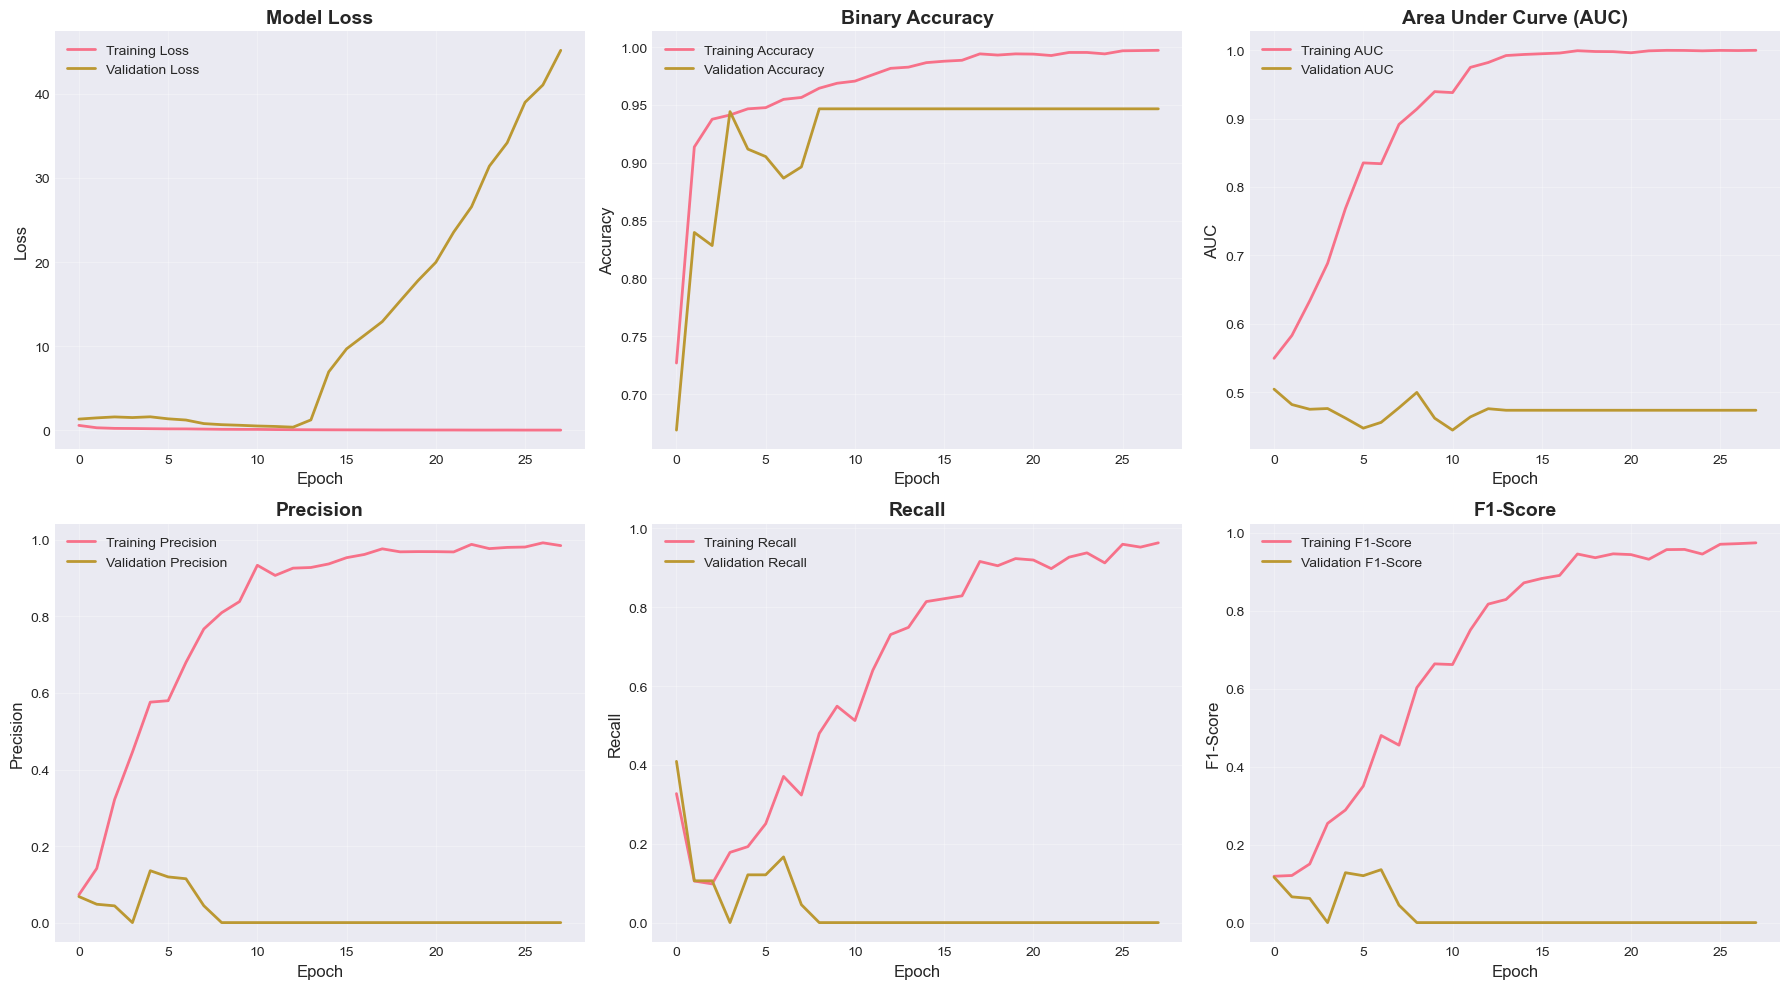


 Beste resultaten:
  Min validation loss: 0.3618
  Max validation accuracy: 0.9466
  Max validation AUC: 0.5045
  Max validation precision: 0.1356
  Max validation recall: 0.4091
  Max validation F1-score: 0.1358


In [ ]:
# Visualiseer training geschiedenis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Binary Accuracy
axes[0, 1].plot(history.history['binary_accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_binary_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Binary Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[0, 2].plot(history.history['auc'], label='Training AUC', linewidth=2)
axes[0, 2].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
axes[0, 2].set_xlabel('Epoch', fontsize=12)
axes[0, 2].set_ylabel('AUC', fontsize=12)
axes[0, 2].set_title('Area Under Curve (AUC)', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Training Precision', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Precision', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Recall', fontsize=12)
axes[1, 1].set_title('Recall', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# F1-Score (berekend uit precision en recall)
train_f1 = 2 * (np.array(history.history['precision']) * np.array(history.history['recall'])) / \
           (np.array(history.history['precision']) + np.array(history.history['recall']) + 1e-7)
val_f1 = 2 * (np.array(history.history['val_precision']) * np.array(history.history['val_recall'])) / \
         (np.array(history.history['val_precision']) + np.array(history.history['val_recall']) + 1e-7)

axes[1, 2].plot(train_f1, label='Training F1-Score', linewidth=2)
axes[1, 2].plot(val_f1, label='Validation F1-Score', linewidth=2)
axes[1, 2].set_xlabel('Epoch', fontsize=12)
axes[1, 2].set_ylabel('F1-Score', fontsize=12)
axes[1, 2].set_title('F1-Score', fontsize=14, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Beste resultaten:")
print(f"  Min validation loss: {min(history.history['val_loss']):.4f}")
print(f"  Max validation accuracy: {max(history.history['val_binary_accuracy']):.4f}")
print(f"  Max validation AUC: {max(history.history['val_auc']):.4f}")
print(f"  Max validation precision: {max(history.history['val_precision']):.4f}")
print(f"  Max validation recall: {max(history.history['val_recall']):.4f}")
print(f"  Max validation F1-score: {max(val_f1):.4f}")

## Stap 12: Predictions & Submission

Nu maken we predictions op de test data en creëren een submission file.

In [ ]:
# Maak predictions op test data
print("Voorspellingen maken op test data...")
y_pred = model.predict(X_test_cnn, batch_size=BATCH_SIZE, verbose=1)

print(f"\n{'='*60}")
print(f"Predictions gemaakt!")
print(f"  Test samples: {len(y_pred)}")
print(f"  Prediction shape: {y_pred.shape}")
print(f"  Prediction range: [{y_pred.min():.4f}, {y_pred.max():.4f}]")

# Bekijk een voorbeeld prediction
example_idx = 0
example_pred = y_pred[example_idx]
example_rec_id = test_rec_ids[example_idx]

print(f"\n📊 Voorbeeld prediction (rec_id {example_rec_id}):")
print(f"Top 5 species (hoogste probabilities):")
top5_indices = np.argsort(example_pred)[-5:][::-1]
for rank, species_idx in enumerate(top5_indices, 1):
    species_name = species_df[species_df['class_id'] == species_idx]['species'].values[0]
    prob = example_pred[species_idx]
    print(f"  {rank}. {species_name:30s}: {prob:.4f}")

Voorspellingen maken op test data...
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step

Predictions gemaakt!
  Test samples: 323
  Prediction shape: (323, 19)
  Prediction range: [0.0000, 0.9769]

📊 Voorbeeld prediction (rec_id 0):
Top 5 species (hoogste probabilities):
  1. Golden Crowned Kinglet        : 0.9663
  2. Swainson's Thrush             : 0.6513
  3. Pacific-slope Flycatcher      : 0.0155
  4. Hermit Thrush                 : 0.0000
  5. Pacific Wren                  : 0.0000

Predictions gemaakt!
  Test samples: 323
  Prediction shape: (323, 19)
  Prediction range: [0.0000, 0.9769]

📊 Voorbeeld prediction (rec_id 0):
Top 5 species (hoogste probabilities):
  1. Golden Crowned Kinglet        : 0.9663
  2. Swainson's Thrush             : 0.6513
  3. Pacific-slope Flycatcher      : 0.0155
  4. Hermit Thrush                 : 0.0000
  5. Pacific Wren                  : 0.0000


In [ ]:
# Maak submission file
print("Creëren van submission file...\n")

# Lees sample submission om het formaat te zien
sample_submission = pd.read_csv(SAMPLE_SUBMISSION)
print("Sample submission format:")
print(sample_submission.head())

# Maak nieuwe submission DataFrame
submission_data = []

for idx, rec_id in enumerate(test_rec_ids):
    pred_probs = y_pred[idx]
    
    # Maak row: rec_id gevolgd door 19 probabilities
    row = [rec_id] + list(pred_probs)
    submission_data.append(row)

# Column namen: rec_id + species IDs
columns = ['rec_id'] + [str(i) for i in range(19)]
submission_df = pd.DataFrame(submission_data, columns=columns)

# Sla submission op
submission_file = BASE_DIR / "submission_cnn_model.csv"
submission_df.to_csv(submission_file, index=False)

print(f"\n{'='*60}")
print(f"✅ Submission file gemaakt!")
print(f"  Bestand: {submission_file}")
print(f"  Samples: {len(submission_df)}")
print(f"\nSubmission preview:")
print(submission_df.head())

Creëren van submission file...

Sample submission format:
   rec_id  species  probability
0       0        0            0
1       0        1            0
2       0        2            0
3       0        3            0
4       0        4            0

✅ Submission file gemaakt!
  Bestand: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\submission_cnn_model.csv
  Samples: 323

Submission preview:
   rec_id             0         1         2             3             4  \
0       0  8.272951e-15  0.000005  0.015456  5.901138e-14  6.548034e-09   
1       1  7.554680e-15  0.000005  0.015283  6.027107e-14  6.622277e-09   
2       4  5.540464e-15  0.000003  0.021441  1.171960e-13  4.518706e-09   
3       6  9.640567e-15  0.000002  0.022326  6.555028e-14  3.278608e-09   
4       7  7.298487e-15  0.000002  0.021106  6.009911e-14  3.428378e-09   

              5         6             7             8             9        10  \
0  1.431779e-22  0.000021  5.149481e-17  3.772673e-11  1.656

## Stap 13: Model Evaluatie

Laten we het model evalueren op de training data (waar we labels hebben).

In [ ]:
# Evalueer op training data (we hebben alleen hier labels)
print("Evaluatie op training data...\n")

y_train_pred = model.predict(X_train_cnn, batch_size=BATCH_SIZE, verbose=0)

# Bereken metrics per species
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

# Voor precision/recall/F1 hebben we binaire predictions nodig (threshold = 0.5)
y_train_pred_binary = (y_train_pred > 0.5).astype(int)

print(f"{'='*100}")
print(f"{'Species':<30} {'AUC':>8} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Samples':>10}")
print(f"{'='*100}")

species_metrics = []
for species_id in range(19):
    species_name = species_df[species_df['class_id'] == species_id]['species'].values[0]
    
    # Bereken metrics voor deze species
    y_true_species = y_train[:, species_id]
    y_pred_species = y_train_pred[:, species_id]
    y_pred_binary_species = y_train_pred_binary[:, species_id]
    
    # Check of we positieve samples hebben
    n_positive = y_true_species.sum()
    
    if n_positive > 0:
        auc = roc_auc_score(y_true_species, y_pred_species)
        precision = precision_score(y_true_species, y_pred_binary_species, zero_division=0)
        recall = recall_score(y_true_species, y_pred_binary_species, zero_division=0)
        f1 = f1_score(y_true_species, y_pred_binary_species, zero_division=0)
    else:
        auc = 0.0
        precision = 0.0
        recall = 0.0
        f1 = 0.0
    
    species_metrics.append({
        'species_id': species_id,
        'species_name': species_name,
        'auc': auc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'n_samples': int(n_positive)
    })
    
    print(f"{species_name:<30} {auc:>8.4f} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {int(n_positive):>10}")

print(f"{'='*100}")

# Overall metrics (gemiddelde over species met samples)
species_with_samples = [m for m in species_metrics if m['n_samples'] > 0]
overall_auc = np.mean([m['auc'] for m in species_with_samples])
overall_precision = np.mean([m['precision'] for m in species_with_samples])
overall_recall = np.mean([m['recall'] for m in species_with_samples])
overall_f1 = np.mean([m['f1_score'] for m in species_with_samples])

print(f"\n📊 Overall Performance (gemiddelde over species met samples):")
print(f"  Mean AUC: {overall_auc:.4f}")
print(f"  Mean Precision: {overall_precision:.4f}")
print(f"  Mean Recall: {overall_recall:.4f}")
print(f"  Mean F1-Score: {overall_f1:.4f}")

Evaluatie op training data...

Species                             AUC  Precision     Recall   F1-Score    Samples
Brown Creeper                    0.4354     0.0000     0.0000     0.0000          7
Pacific Wren                     0.7779     0.0000     0.0000     0.0000         35
Pacific-slope Flycatcher         0.5594     0.0000     0.0000     0.0000         21
Red-breasted Nuthatch            0.3954     0.0000     0.0000     0.0000          4
Dark-eyed Junco                  0.6251     0.0000     0.0000     0.0000         13
Olive-sided Flycatcher           0.4244     0.0000     0.0000     0.0000          8
Hermit Thrush                    0.3995     0.0000     0.0000     0.0000         25
Chestnut-backed Chickadee        0.4039     0.0000     0.0000     0.0000         22
Varied Thrush                    0.5239     0.0000     0.0000     0.0000         29
Hermit Warbler                   0.6116     0.0000     0.0000     0.0000         25
Swainson's Thrush                0.5024     0

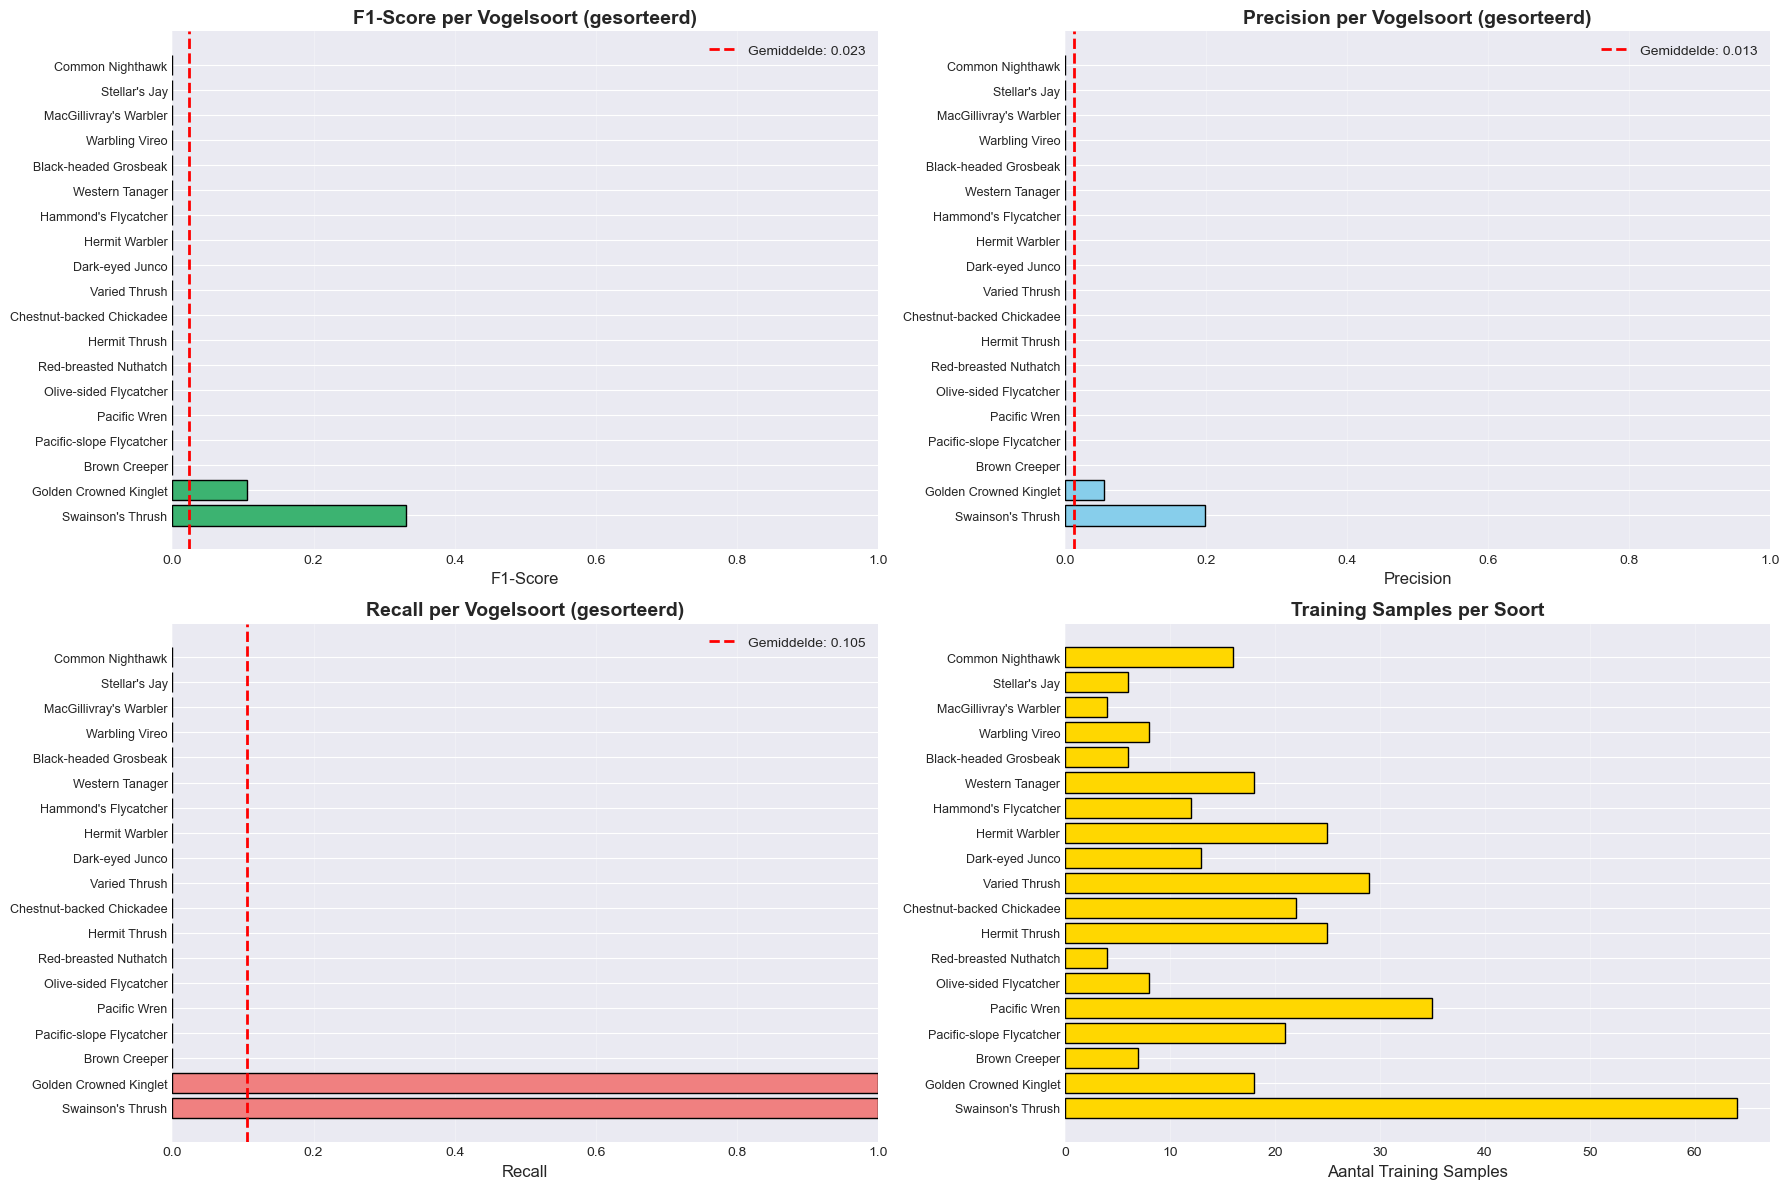


🎯 Top 5 Best Performing Species (op basis van F1-Score):
  Swainson's Thrush              - F1: 0.3316, Precision: 0.1988, Recall: 1.0000 (64 samples)
  Golden Crowned Kinglet         - F1: 0.1059, Precision: 0.0559, Recall: 1.0000 (18 samples)
  Brown Creeper                  - F1: 0.0000, Precision: 0.0000, Recall: 0.0000 (7 samples)
  Pacific-slope Flycatcher       - F1: 0.0000, Precision: 0.0000, Recall: 0.0000 (21 samples)
  Pacific Wren                   - F1: 0.0000, Precision: 0.0000, Recall: 0.0000 (35 samples)

⚠️ Bottom 5 Species (need improvement):
  Black-headed Grosbeak          - F1: 0.0000, Precision: 0.0000, Recall: 0.0000 (6 samples)
  Warbling Vireo                 - F1: 0.0000, Precision: 0.0000, Recall: 0.0000 (8 samples)
  MacGillivray's Warbler         - F1: 0.0000, Precision: 0.0000, Recall: 0.0000 (4 samples)
  Stellar's Jay                  - F1: 0.0000, Precision: 0.0000, Recall: 0.0000 (6 samples)
  Common Nighthawk               - F1: 0.0000, Precision: 0.

In [ ]:
# Visualiseer performance per species
species_metrics_df = pd.DataFrame(species_metrics)
species_metrics_df = species_metrics_df[species_metrics_df['n_samples'] > 0].sort_values('f1_score', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. F1-Score per species
axes[0, 0].barh(range(len(species_metrics_df)), species_metrics_df['f1_score'], 
                color='mediumseagreen', edgecolor='black')
axes[0, 0].set_yticks(range(len(species_metrics_df)))
axes[0, 0].set_yticklabels([s[:25] for s in species_metrics_df['species_name']], fontsize=9)
axes[0, 0].set_xlabel('F1-Score', fontsize=12)
axes[0, 0].set_title('F1-Score per Vogelsoort (gesorteerd)', fontsize=14, fontweight='bold')
axes[0, 0].axvline(overall_f1, color='red', linestyle='--', linewidth=2, 
                   label=f'Gemiddelde: {overall_f1:.3f}')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].set_xlim([0, 1])

# 2. Precision per species
axes[0, 1].barh(range(len(species_metrics_df)), 
                species_metrics_df.sort_values('precision', ascending=False)['precision'], 
                color='skyblue', edgecolor='black')
axes[0, 1].set_yticks(range(len(species_metrics_df)))
axes[0, 1].set_yticklabels([s[:25] for s in species_metrics_df.sort_values('precision', ascending=False)['species_name']], 
                           fontsize=9)
axes[0, 1].set_xlabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision per Vogelsoort (gesorteerd)', fontsize=14, fontweight='bold')
axes[0, 1].axvline(overall_precision, color='red', linestyle='--', linewidth=2, 
                   label=f'Gemiddelde: {overall_precision:.3f}')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].set_xlim([0, 1])

# 3. Recall per species
axes[1, 0].barh(range(len(species_metrics_df)), 
                species_metrics_df.sort_values('recall', ascending=False)['recall'], 
                color='lightcoral', edgecolor='black')
axes[1, 0].set_yticks(range(len(species_metrics_df)))
axes[1, 0].set_yticklabels([s[:25] for s in species_metrics_df.sort_values('recall', ascending=False)['species_name']], 
                           fontsize=9)
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_title('Recall per Vogelsoort (gesorteerd)', fontsize=14, fontweight='bold')
axes[1, 0].axvline(overall_recall, color='red', linestyle='--', linewidth=2, 
                   label=f'Gemiddelde: {overall_recall:.3f}')
axes[1, 0].legend()
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].set_xlim([0, 1])

# 4. Aantal samples per species
axes[1, 1].barh(range(len(species_metrics_df)), species_metrics_df['n_samples'], 
                color='gold', edgecolor='black')
axes[1, 1].set_yticks(range(len(species_metrics_df)))
axes[1, 1].set_yticklabels([s[:25] for s in species_metrics_df['species_name']], fontsize=9)
axes[1, 1].set_xlabel('Aantal Training Samples', fontsize=12)
axes[1, 1].set_title('Training Samples per Soort', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎯 Top 5 Best Performing Species (op basis van F1-Score):")
for idx, row in species_metrics_df.head(5).iterrows():
    print(f"  {row['species_name']:30s} - F1: {row['f1_score']:.4f}, "
          f"Precision: {row['precision']:.4f}, Recall: {row['recall']:.4f} "
          f"({row['n_samples']} samples)")

print("\n⚠️ Bottom 5 Species (need improvement):")
for idx, row in species_metrics_df.tail(5).iterrows():
    print(f"  {row['species_name']:30s} - F1: {row['f1_score']:.4f}, "
          f"Precision: {row['precision']:.4f}, Recall: {row['recall']:.4f} "
          f"({row['n_samples']} samples)")